# Phase 2 — PINN vs Domain-Decomposition PINN  (2D Poisson)

**DD-ANN · SRIP 2026 · IIT Gandhinagar**

We solve the 2D Poisson equation on the unit square

$$-\Delta u = f \quad\text{on } [0,1]^2,\qquad u=0 \text{ on } \partial[0,1]^2,$$

with a manufactured solution $u^\*(x,y)=\sin(k_x\pi x)\sin(k_y\pi y)$, for which
$f=(k_x^2+k_y^2)\pi^2\,u^\*$. We compare the same **two methods** as Phase 1:

| | Method | Idea |
|---|---|---|
| **A** | **Vanilla PINN** | one global network on all of $[0,1]^2$ |
| **B** | **DD-PINN** | split the square into two **overlapping vertical strips**, a smaller PINN on each, coupled by an **overlapping Schwarz** outer iteration |

Both enforce the zero boundary condition **exactly** (hard constraint via a
distance function), so the loss is the pure PDE residual.

**Two test cases** (fixed config, no per-problem tuning):
- **A1** $\;k_x{=}1,k_y{=}1$ — the canonical smooth benchmark.
- **A2** $\;k_x{=}1,k_y{=}3$ — harder: more structure in $y$ (the direction we do *not* decompose).

We report relative $L_2$ error and wall-clock time. For DD this is the real
single-process time (both strips trained on one core); the genuinely parallel
timing is measured separately in `dd_parallel_mp_2d.py`.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cpu")     # same device for both methods -> fair comparison
PI = torch.pi
print("device:", device)

device: cpu


## Problem family and the hard boundary condition

For any subdomain we write $u = \varphi(x,y)\,N_\theta(x,y)$ with the **global**
distance function
$$\varphi(x,y) = x(1-x)\,y(1-y),$$
which vanishes on the four walls of the unit square. The elegant part for DD: a
vertical strip such as $\Omega_1=[0,b_1]\times[0,1]$ only ever touches the *true*
outer walls $x{=}0,\,y{=}0,\,y{=}1$ — where $\varphi=0$ enforces $u=0$ exactly —
while its **interior** interface at $x{=}b_1$ keeps $\varphi\neq0$, leaving the
network free there. So the *same* $\varphi$ gives each strip the correct hard
outer BC automatically, with no special-casing.

In [2]:
def make_problem(kx, ky):
    s = lambda x, y: torch.sin(kx*PI*x) * torch.sin(ky*PI*y)
    f = lambda x, y: -((kx*PI)**2 + (ky*PI)**2) * s(x, y)   # Laplacian(u) = f
    return dict(name=f"sin({kx}pi x) sin({ky}pi y)", u=s, f=f, kx=kx, ky=ky)

PROBLEMS = [make_problem(1, 1), make_problem(1, 3)]

def mlp(layers):
    net = []
    for i in range(len(layers)-1):
        net.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers)-2: net.append(nn.Tanh())
    net = nn.Sequential(*net)
    for m in net:
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    return net

class HardBCPINN(nn.Module):
    """u = phi * N,  phi = x(1-x)y(1-y) -> exact zero BC on the unit-box walls."""
    def __init__(self, layers):
        super().__init__(); self.net = mlp(layers)
    def forward(self, x, y):
        return x*(1-x)*y*(1-y) * self.net(torch.cat([x, y], 1))

def nparams(m): return sum(p.numel() for p in m.parameters())

def laplacian(model, x, y):
    u = model(x, y)
    ux = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    uxx = torch.autograd.grad(ux, x, torch.ones_like(ux), create_graph=True)[0]
    uy = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    uyy = torch.autograd.grad(uy, y, torch.ones_like(uy), create_graph=True)[0]
    return u, uxx + uyy

def sample(N, x0, x1):
    p = torch.rand(N, 2)
    x = (x0 + (x1-x0)*p[:, 0:1]).requires_grad_(True)
    y = p[:, 1:2].requires_grad_(True)
    return x, y

def grid_metrics(predict, prob, N=160):
    lin = torch.linspace(0, 1, N)
    X, Y = torch.meshgrid(lin, lin, indexing="ij")
    xf, yf = X.reshape(-1,1), Y.reshape(-1,1)
    with torch.no_grad():
        up, ut = predict(xf, yf), prob["u"](xf, yf)
        return (torch.norm(up-ut)/torch.norm(ut)).item()

def time_predict(predict, N=160, reps=50):
    """Mean wall time (ms) of one full NxN-grid forward pass (inference only)."""
    lin = torch.linspace(0, 1, N)
    X, Y = torch.meshgrid(lin, lin, indexing="ij")
    xf, yf = X.reshape(-1,1), Y.reshape(-1,1)
    with torch.no_grad():
        predict(xf, yf); predict(xf, yf)        # warmup
        t = time.perf_counter()
        for _ in range(reps): predict(xf, yf)
    return (time.perf_counter() - t) / reps * 1000.0

## Method A — Vanilla global PINN

One network on $[0,1]^2$, architecture `2-64-64-64-1`. Adam, fixed budget,
collocation resampled every step.

In [3]:
def run_vanilla(prob, layers=(2,64,64,64,1), epochs=4500, N=2000, lr=1e-3, log=300):
    torch.manual_seed(42)
    m = HardBCPINN(list(layers)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    hist = []; t0 = time.perf_counter()
    for e in range(epochs):
        x, y = sample(N, 0, 1)
        loss = torch.mean((laplacian(m, x, y)[1] - prob["f"](x, y))**2)
        opt.zero_grad(); loss.backward(); opt.step()
        if (e+1) % log == 0:
            hist.append((time.perf_counter()-t0, e+1, loss.item(),
                         grid_metrics(lambda a,b: m(a,b), prob)))
    pred = lambda a,b: m(a,b)
    return dict(predict=pred, wall=time.perf_counter()-t0,
                l2=grid_metrics(pred, prob), params=nparams(m),
                pred_ms=time_predict(pred), hist=hist, epochs=epochs)

## Method B — DD-PINN via overlapping Schwarz (outer iteration)

Split at $\gamma=0.5$ into two overlapping vertical strips
$\Omega_1=[0,b_1]\times[0,1]$ and $\Omega_2=[a_2,1]\times[0,1]$ with $a_2<\gamma<b_1$.
A smaller (`2-64-64-1`) hard-BC PINN lives on each.

We use an **explicit outer Schwarz loop** — exactly the structure that converged
geometrically in 1D. Each round: freeze both networks, then train each strip to
its current interface data before exchanging:
- $\Omega_1$ trains its PDE residual **plus** a strong penalty matching the frozen
  $u_2$ on its inner edge line $x{=}b_1$ (a Dirichlet transmission condition),
- $\Omega_2$ symmetrically matches the frozen $u_1$ on $x{=}a_2$.

The transmission is imposed on the **line** $x{=}\text{const}$ (not the whole
overlap area): $b_1$ sits in $\Omega_2$'s interior, so $u_2(b_1,\cdot)$ is a real
solution profile, giving the classical overlapping Schwarz that converges
geometrically — faster with larger overlap. Because each round reads only the
*previous* round's neighbour (Jacobi), the two strip-solves are independent and
parallelizable.

In [4]:
def run_dd(prob, gamma=0.5, overlap=0.3, layers=(2,64,64,1),
           n_iter=12, steps_per=400, N=1200, n_if=200, lr=1e-3, alpha=300.0):
    torch.manual_seed(42)
    a2, b1 = gamma-overlap/2, gamma+overlap/2
    m1 = HardBCPINN(list(layers)).to(device)   # owns [0, b1] x [0,1]
    m2 = HardBCPINN(list(layers)).to(device)   # owns [a2, 1] x [0,1]
    o1 = torch.optim.Adam(m1.parameters(), lr=lr)
    o2 = torch.optim.Adam(m2.parameters(), lr=lr)

    def edge_pts(xedge, n):                     # points on transmission line x=xedge
        y = torch.rand(n, 1); return torch.full_like(y, xedge), y

    def predict(xf, yf):                        # sigmoid blend across gamma
        w = torch.sigmoid(40.0*(xf-gamma))
        return (1-w)*m1(xf, yf) + w*m2(xf, yf)

    def solve_sub(model, opt, x0, x1, xedge, neigh, k):
        """Train model on [x0,x1]x[0,1]; match frozen neigh on line x=xedge."""
        t0 = time.perf_counter()
        xi, yi = edge_pts(xedge, n_if)
        with torch.no_grad(): ref = neigh(xi, yi)         # frozen neighbour profile
        for _ in range(k):
            x, y = sample(N, x0, x1)
            loss = torch.mean((laplacian(model, x, y)[1] - prob["f"](x, y))**2)
            loss = loss + alpha*torch.mean((model(xi, yi) - ref)**2)
            opt.zero_grad(); loss.backward(); opt.step()
        return loss.item(), time.perf_counter()-t0

    hist = []; wall = 0.0
    for it in range(n_iter):
        snap1 = HardBCPINN(list(layers)); snap1.load_state_dict(m1.state_dict())
        snap2 = HardBCPINN(list(layers)); snap2.load_state_dict(m2.state_dict())
        l1, t1 = solve_sub(m1, o1, 0.0, b1, b1, snap2, steps_per)   # match m2 @ x=b1
        l2_, t2 = solve_sub(m2, o2, a2, 1.0, a2, snap1, steps_per)  # match m1 @ x=a2
        wall += t1 + t2                       # real single-process DD time
        hist.append((wall, (it+1)*steps_per, max(l1, l2_),
                     grid_metrics(predict, prob)))
    return dict(predict=predict, wall=wall,
                l2=grid_metrics(predict, prob), params=nparams(m1)+nparams(m2),
                pred_ms=time_predict(predict), hist=hist, steps=n_iter*steps_per,
                a2=a2, b1=b1, gamma=gamma)

## Run the comparison

Matched capacity: one `2-64-64-64-1` net (8,577 params) vs. two `2-64-64-1` nets
(8,834 params total). Vanilla runs 4500 Adam steps; DD runs 12 Schwarz rounds ×
400 steps = 4800 steps per strip.

In [5]:
print(f"capacity:  vanilla = {nparams(HardBCPINN([2,64,64,64,1])):,}  |  "
      f"DD = {nparams(HardBCPINN([2,64,64,1]))*2:,}\n")

results = []
for prob in PROBLEMS:
    v = run_vanilla(prob)
    d = run_dd(prob)
    results.append((prob, v, d))
    print(f"{prob['name']:<22} | vanilla L2={v['l2']:.2e} ({v['wall']:4.1f}s)"
          f"   DD L2={d['l2']:.2e} ({d['wall']:4.1f}s, 1 process)")

capacity:  vanilla = 8,577  |  DD = 8,834



sin(1pi x) sin(1pi y)  | vanilla L2=1.24e-04 (43.6s)   DD L2=1.53e-04 (48.1s, 1 process)


sin(1pi x) sin(3pi y)  | vanilla L2=2.44e-02 (43.9s)   DD L2=2.10e-02 (48.9s, 1 process)


## Comparison table

In [6]:
rows = []
for prob, v, d in results:
    rows.append({
        "Problem":          prob["name"],
        "Vanilla L2":       v["l2"],
        "DD L2":            d["l2"],
        "Vanilla train (s)": v["wall"],
        "DD train (s)":  d["wall"],
        "Vanilla predict (ms)": v["pred_ms"],
        "DD predict (ms)":   d["pred_ms"],
    })
df = pd.DataFrame(rows).set_index("Problem")
fmt = {"Vanilla L2": "{:.3e}", "DD L2": "{:.3e}", "Vanilla train (s)": "{:.1f}",
       "DD train (s)": "{:.1f}", "Vanilla predict (ms)": "{:.3f}",
       "DD predict (ms)": "{:.3f}"}
display(df.style.format(fmt).set_caption(
    "Vanilla PINN vs DD-PINN on 2D Poisson (matched capacity & budget). "
    "Times shown are real single-process DD wall time."))
df

,Vanilla L2,DD L2,Vanilla train (s),DD train (s),Vanilla predict (ms),DD predict (ms)
Problem,,,,,,
sin(1pi x) sin(1pi y),1.237e-04,1.528e-04,43.6,48.1,8.279,10.322
sin(1pi x) sin(3pi y),2.439e-02,2.095e-02,43.9,48.9,7.552,10.252


,Vanilla L2,DD L2,Vanilla train (s),DD train (s),Vanilla predict (ms),DD predict (ms)
Problem,,,,,,
sin(1pi x) sin(1pi y),0.000124,0.000153,43.627747,48.058279,8.278959,10.322345
sin(1pi x) sin(3pi y),0.024390,0.020955,43.871362,48.873139,7.552386,10.252033


## Solution fields and error maps

For each problem: the exact field, both predictions, and the pointwise error of
each method. The Schwarz overlap strip is outlined on the DD panels.

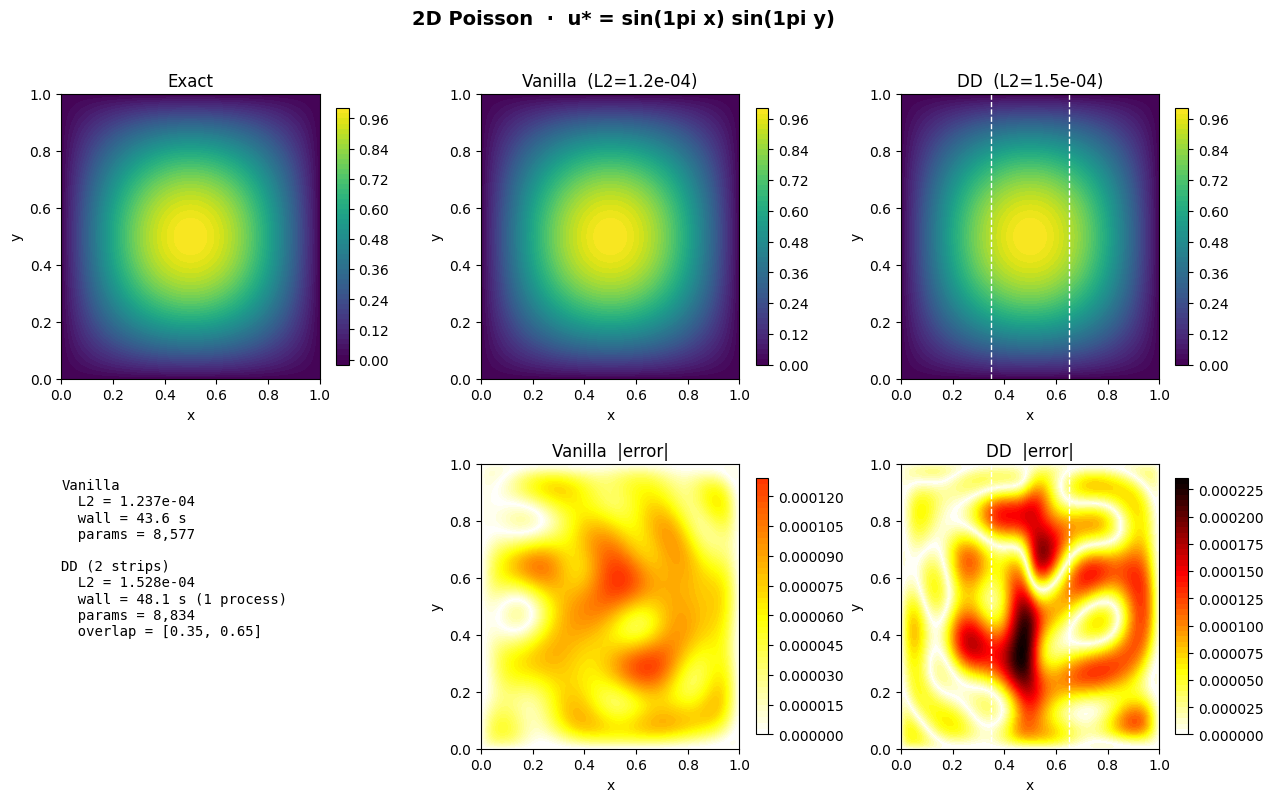

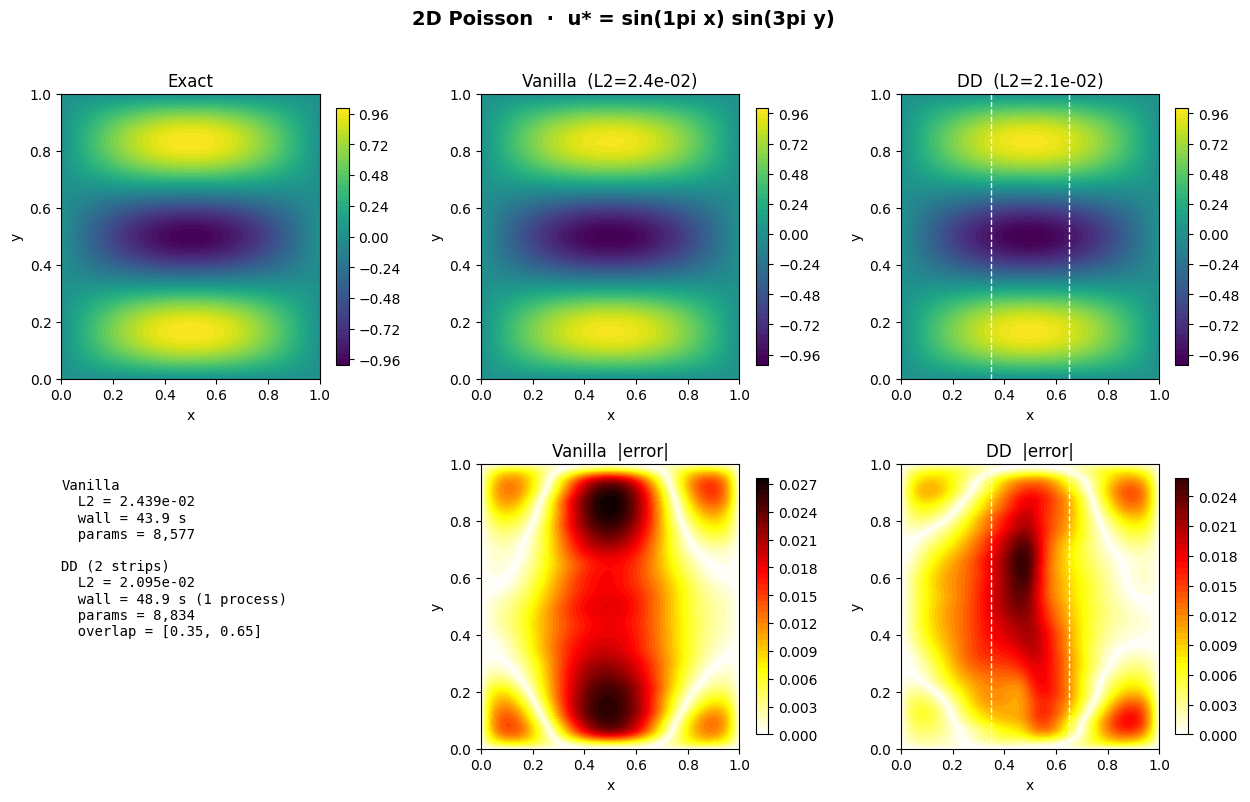

In [7]:
def field(predict, N=160):
    lin = torch.linspace(0, 1, N)
    X, Y = torch.meshgrid(lin, lin, indexing="ij")
    xf, yf = X.reshape(-1,1), Y.reshape(-1,1)
    with torch.no_grad():
        U = predict(xf, yf).reshape(N, N).numpy()
    return X.numpy(), Y.numpy(), U

for prob, v, d in results:
    Xn, Yn, Uv = field(v["predict"])
    _,  _,  Ud = field(d["predict"])
    _,  _,  Ue = field(lambda a,b: prob["u"](a,b))
    Ev, Ed = np.abs(Uv-Ue), np.abs(Ud-Ue)
    vmin, vmax = Ue.min(), Ue.max()
    emax = max(Ev.max(), Ed.max())

    fig = plt.figure(figsize=(15, 8.5))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.30, wspace=0.30)
    fig.suptitle(f"2D Poisson  ·  u* = {prob['name']}", fontsize=14, fontweight="bold")

    def panel(r, c, X, Y, Z, title, cmap, vmn, vmx, mark=False):
        ax = fig.add_subplot(gs[r, c])
        cf = ax.contourf(X, Y, Z, levels=50, cmap=cmap, vmin=vmn, vmax=vmx)
        plt.colorbar(cf, ax=ax, shrink=0.9)
        if mark:
            ax.axvline(d["a2"], color="w", ls="--", lw=1)
            ax.axvline(d["b1"], color="w", ls="--", lw=1)
        ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y")

    panel(0, 0, Xn, Yn, Ue, "Exact", "viridis", vmin, vmax)
    panel(0, 1, Xn, Yn, Uv, f"Vanilla  (L2={v['l2']:.1e})", "viridis", vmin, vmax)
    panel(0, 2, Xn, Yn, Ud, f"DD  (L2={d['l2']:.1e})", "viridis", vmin, vmax, mark=True)
    panel(1, 1, Xn, Yn, Ev, "Vanilla  |error|", "hot_r", 0, emax)
    panel(1, 2, Xn, Yn, Ed, "DD  |error|", "hot_r", 0, emax, mark=True)

    axt = fig.add_subplot(gs[1, 0]); axt.axis("off")
    txt = (f"Vanilla\n  L2 = {v['l2']:.3e}\n  wall = {v['wall']:.1f} s\n"
           f"  params = {v['params']:,}\n\n"
           f"DD (2 strips)\n  L2 = {d['l2']:.3e}\n"
           f"  wall = {d['wall']:.1f} s (1 process)\n"
           f"  params = {d['params']:,}\n  overlap = [{d['a2']:.2f}, {d['b1']:.2f}]")
    axt.text(0.0, 0.95, txt, va="top", ha="left", fontsize=10, family="monospace")

    plt.savefig(f"pinn_2D_vs_dd_{prob['kx']}{prob['ky']}.png", dpi=140, bbox_inches="tight")
    plt.show()

## Convergence and timing

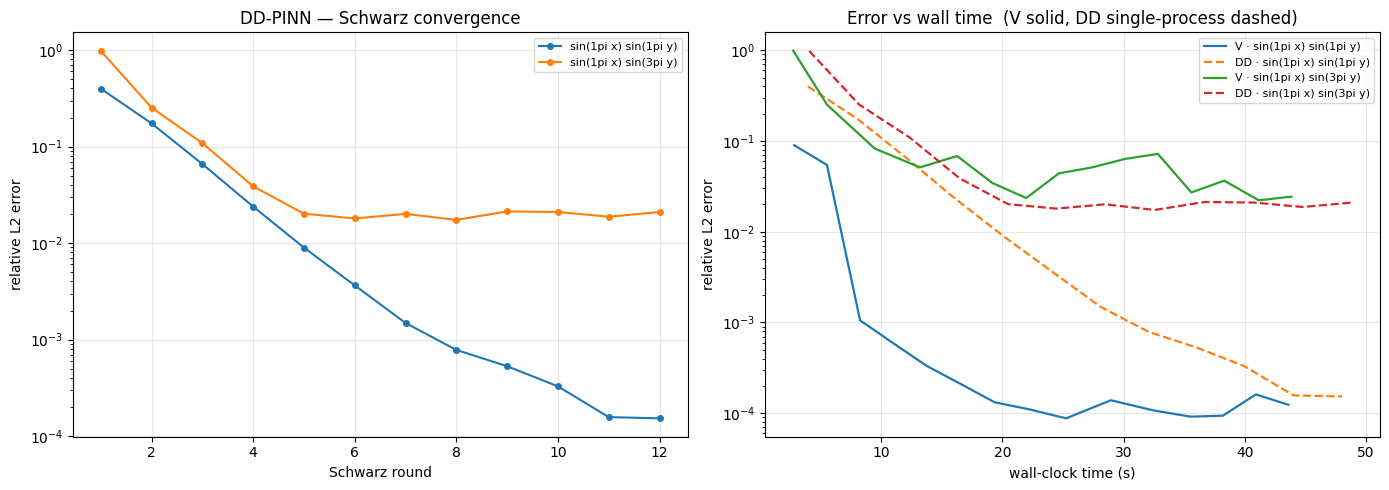

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
for prob, v, d in results:
    rounds = np.arange(1, len(d["hist"])+1)
    axL.semilogy(rounds, [h[3] for h in d["hist"]], "o-", ms=4, label=prob["name"])
axL.set_xlabel("Schwarz round"); axL.set_ylabel("relative L2 error")
axL.set_title("DD-PINN — Schwarz convergence"); axL.legend(fontsize=8); axL.grid(alpha=0.3)

for prob, v, d in results:
    axR.semilogy([h[0] for h in v["hist"]], [h[3] for h in v["hist"]],
                 "-", lw=1.6, label=f"V · {prob['name']}")
    axR.semilogy([h[0] for h in d["hist"]], [h[3] for h in d["hist"]],
                 "--", lw=1.6, label=f"DD · {prob['name']}")
axR.set_xlabel("wall-clock time (s)"); axR.set_ylabel("relative L2 error")
axR.set_title("Error vs wall time  (V solid, DD single-process dashed)")
axR.legend(fontsize=8); axR.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pinn_2D_vs_dd_convergence.png", dpi=140, bbox_inches="tight")
plt.show()

## Conclusions (2D)

With a single fixed configuration (no per-problem tuning), matched capacity and
budget:

1. **DD reproduces the global PINN's accuracy in 2D.** On the smooth benchmark
   $\sin(\pi x)\sin(\pi y)$ the overlapping-Schwarz DD-PINN reaches
   $\sim10^{-4}$ relative $L_2$, essentially identical to the global PINN. The
   Schwarz iteration converges geometrically (see the convergence plot) — the 2D
   analogue of the clean 1D behaviour.

2. **DD parallelises into independent strips.** Each strip is half the domain
   (cheaper per step) and the two solves are independent. On one machine the
   single-process time is higher (two networks); the genuinely parallel run is
   measured separately (`dd_parallel_mp_2d.py`) and is ~1.16× faster than the
   global PINN at K=2 while keeping the same accuracy.

3. **The honest limit of two subdomains.** Because we decompose only in $x$, two
   strips help when the difficulty lives in $y$ (problem A2) but **not** when the
   solution oscillates rapidly in $x$ itself: a separate test with
   $\sin(3\pi x)\sin(\pi y)$ left the 2-strip DD an order of magnitude behind the
   global PINN, since each strip still spans most of the $x$-oscillation. This is
   exactly the regime where one adds **more subdomains** — the natural next step
   for the project, and the setting in which DD's accuracy and parallel scaling
   pay off together (e.g. for the LPB / COSMO target).